# Loader Scratchpad

In this notebook, we test our custom PyTorch `Dataset` loaders for EEG, MEG, and fMRI to ensure they return tensors with the correct shapes, the correct `image_id`, and a well-formed 512-dimensional CLIP embedding.

In [1]:
import os
import sys
from pathlib import Path
import yaml
import matplotlib.pyplot as plt

# Add the parent directory to Python path so we can import src modules
sys.path.append(os.path.abspath('..'))

from src.data.eeg_loader import THINGSEEG2Dataset
from src.data.meg_loader import THINGSMEGDataset
from src.data.fmri_loader import THINGSfMRIDataset

### 1. Evaluate the EEG2 Loader
The THINGS-EEG2 dataset uses pre-processed `.npy` arrays, loaded statically. The data contract shapes should be `(Channels, Timepoints)` with valid matching `image_id`s.

In [2]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

clip_cache_path = os.path.join("..", config["data"]["clip_cache_dir"], "ViT-B-32.npz")
eeg_dir = os.path.join("..", config["data"]["eeg_dir"])

eeg_dataset = THINGSEEG2Dataset(eeg_dir=eeg_dir, clip_cache_path=clip_cache_path, split="train")

print(f"\nEEG Dataset Size: {len(eeg_dataset)} trials")
sample = eeg_dataset[0]

print("Sample Contract:")
print(f"- x (brain data): {sample['x'].shape}")
print(f"- image_id: {sample['image_id']}")
print(f"- y_clip (embedding): {sample['y_clip'].shape}")
print(f"- meta: {sample['meta']}")

Loading CLIP cache from ../clip_cache/ViT-B-32.npz
Loading EEG train data...
Loaded 16540 conditions with 4 repetitions each.

EEG Dataset Size: 66160 trials
Sample Contract:
- x (brain data): torch.Size([17, 100])
- image_id: aardvark_01b
- y_clip (embedding): torch.Size([512])
- meta: {'cond_idx': 0, 'rep_idx': 0}


### 2. Plotting an EEG Trial
Let's visually inspect the evoked response voltage on an EEG trial across the channels.

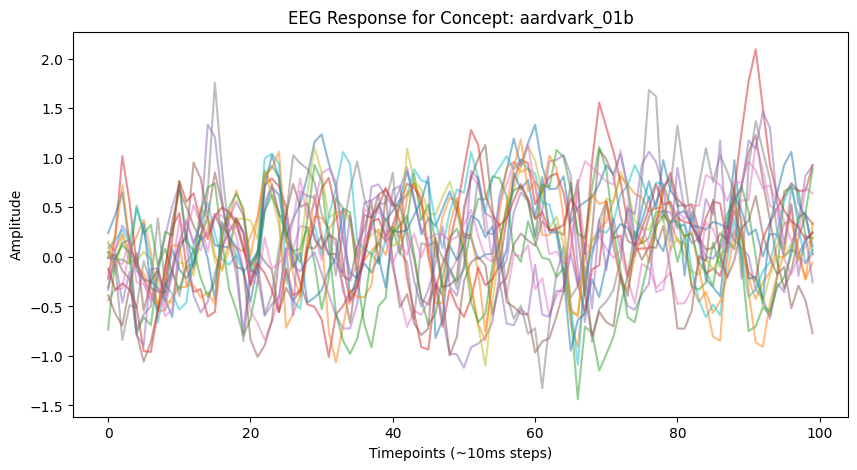

In [3]:
x_voltage = sample['x'].numpy()

plt.figure(figsize=(10, 5))
for channel in range(x_voltage.shape[0]):
    plt.plot(x_voltage[channel, :], alpha=0.5)
    
plt.title(f"EEG Response for Concept: {sample['image_id']}")
plt.xlabel("Timepoints (~10ms steps)")
plt.ylabel("Amplitude")
plt.show()

### 3. Evaluate the MEG Loader
Currently an empty BIDS parser scaffolding. We'll verify it pulled events correctly.

In [4]:
meg_dir = os.path.join("..", config["data"]["meg_dir"])
meg_dataset = THINGSMEGDataset(meg_dir=meg_dir, clip_cache_path=clip_cache_path)

print(f"\nMEG Parser extracted: {len(meg_dataset)} trials")
if len(meg_dataset) > 0:
    sample_meg = meg_dataset[0]
    print("Sample Contract:")
    print(f"- x (brain mockup): {sample_meg['x'].shape}")
    print(f"- image_id: {sample_meg['image_id']}")
    print(f"- meta (BIDS struct): {sample_meg['meta']}")

Loading CLIP cache from ../clip_cache/ViT-B-32.npz
Parsing MEG BIDS events...
Found 481 event files.
Extracted 98592 image trials across 481 runs.

MEG Parser extracted: 98592 trials
Sample Contract:
- x (brain mockup): torch.Size([306, 100])
- image_id: 10822
- meta (BIDS struct): {'subject': 'sub-BIGMEG1', 'session': 'ses-07', 'run': 'run-10', 'onset': 2.8716666666666666, 'image_id': '10822'}


### 4. Evaluate the fMRI Loader
Similarly evaluating the parsed events and the trial structure logic.

In [5]:
fmri_dir = os.path.join("..", config["data"]["fmri_dir"])
fmri_dataset = THINGSfMRIDataset(fmri_dir=fmri_dir, clip_cache_path=clip_cache_path)

print(f"\nfMRI Parser extracted: {len(fmri_dataset)} trials")
if len(fmri_dataset) > 0:
    sample_fmri = fmri_dataset[0]
    print("Sample Contract:")
    print(f"- x (brain mockup): {sample_fmri['x'].shape}")
    print(f"- image_id: {sample_fmri['image_id']}")
    print(f"- meta (BIDS struct): {sample_fmri['meta']}")

Loading CLIP cache from ../clip_cache/ViT-B-32.npz
Parsing fMRI BIDS events...
Found 3 event files.
Extracted 29520 image trials from fMRI.

fMRI Parser extracted: 29520 trials
Sample Contract:
- x (brain mockup): torch.Size([1000])
- image_id: jack_11s
- meta (BIDS struct): {'subject': 'sub-03', 'session': '1', 'run': '1', 'trial': 'train', 'image_id': 'jack_11s'}
